In [1]:
from collections import defaultdict

import gymnasium as gym

import numpy as np

In [2]:
class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        lr: float = 0.01,
        initial_epsilon: float = 1.0,
        epsilon_decay: float = 1e-5,
        final_epsilon: float = 0.1,
        discount_factor: float = 0.95):

        """
        Args:
            env: training environment
            lr: learning rate to how quickly to update q-values (0-1)
            initial_epsilon: beginning exploration rate 
            epsilon_decay: How much to reduce epsilon
            final_epsilon: Minimum exploration rate
            discount_factor: How much to value future rewards
        """

        self.env = env
        self.lr = lr

        # Q-talbes: maps (state, action) to expect reward
        # defaultdict automatically create entries with zero for new states
        self.q_values = defaultdict(lambda: np.zeros(self.env.action_space.n))

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.discount_factor = discount_factor

        self.training_err = []


    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """
            Choose an action using epsilon-greedy strategy
            returns: action 0 (stand) or 1 (hit)
        """

        # with probability epsilon, take random action
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()

        # otherwise, exploit 
        else:
            return np.argmax(self.q_values[obs])

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
        ):
        """ Update Q-value based on experiences
        Learn from (state, action, reward, next state)
        """

        # what is the best we could do from the next state?
        # zero if episode terminated, no future rewards possible
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])

        # what should the q value be? ( bellman equation )
        target = reward + self.discount_factor * future_q_value

        # what wrong is the current estimate?
        temporal_diff = target - self.q_values[obs][action]

        # update our estiamte in the direction of the error
        # lr control the step
        self.q_values[obs][action] = ( self.q_values[obs][action] +
                                      self.lr * temporal_diff)
        
        # track learning progress
        self.training_err.append(temporal_diff)


    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)




In [3]:
# # current esimate q(state,action)
# current_q = self.q_values[obs][action]

# # what we experience : reward + discounted future value
# target = reward + self.discount_factor + max(self.q_values[next_obs])

# # how wrong
# errpr = target - current_q

# # update estimate:
# new_q = current_q + self.lr * error

In [10]:
lr = 0.01

n_episodes = int(1e5)

start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes/2)
final_epsilon = 0.1

env = gym.make("Blackjack-v1", sab=False)
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length = n_episodes)

agent = BlackjackAgent(
    env = env,
    lr = lr,
    initial_epsilon = start_epsilon,
    epsilon_decay = epsilon_decay,
    final_epsilon = final_epsilon)


In [14]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    while not done:
        # agent choose action (initially random, gradually more intelligent)
        action = agent.get_action(obs)

        # take action, observe result
        next_obs, rewards, terminated, truncated, info = env.step(action)

        # learn from experience
        agent.update(obs, action, rewards, terminated, next_obs)

        # move to the next state
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()
    if episode % 10000 == 0:
        print(f'reward: {rewards}, obs: {obs}, terminated: {terminated}, truncated: {truncated}')

  6%|▌         | 5843/100000 [00:00<00:03, 29258.52it/s]

reward: 0.0, obs: (18, 10, 0), terminated: True, truncated: False


 15%|█▍        | 14737/100000 [00:00<00:03, 27853.12it/s]

reward: 1.0, obs: (19, 6, 0), terminated: True, truncated: False


 23%|██▎       | 23127/100000 [00:00<00:02, 27448.28it/s]

...

 84%|████████▍ | 83948/100000 [00:02<00:00, 29390.77it/s]

reward: 1.0, obs: (21, 10, 1), terminated: True, truncated: False


 96%|█████████▌| 95761/100000 [00:03<00:00, 27895.71it/s]

reward: -1.0, obs: (22, 5, 0), terminated: True, truncated: False


100%|██████████| 100000/100000 [00:03<00:00, 28590.00it/s]


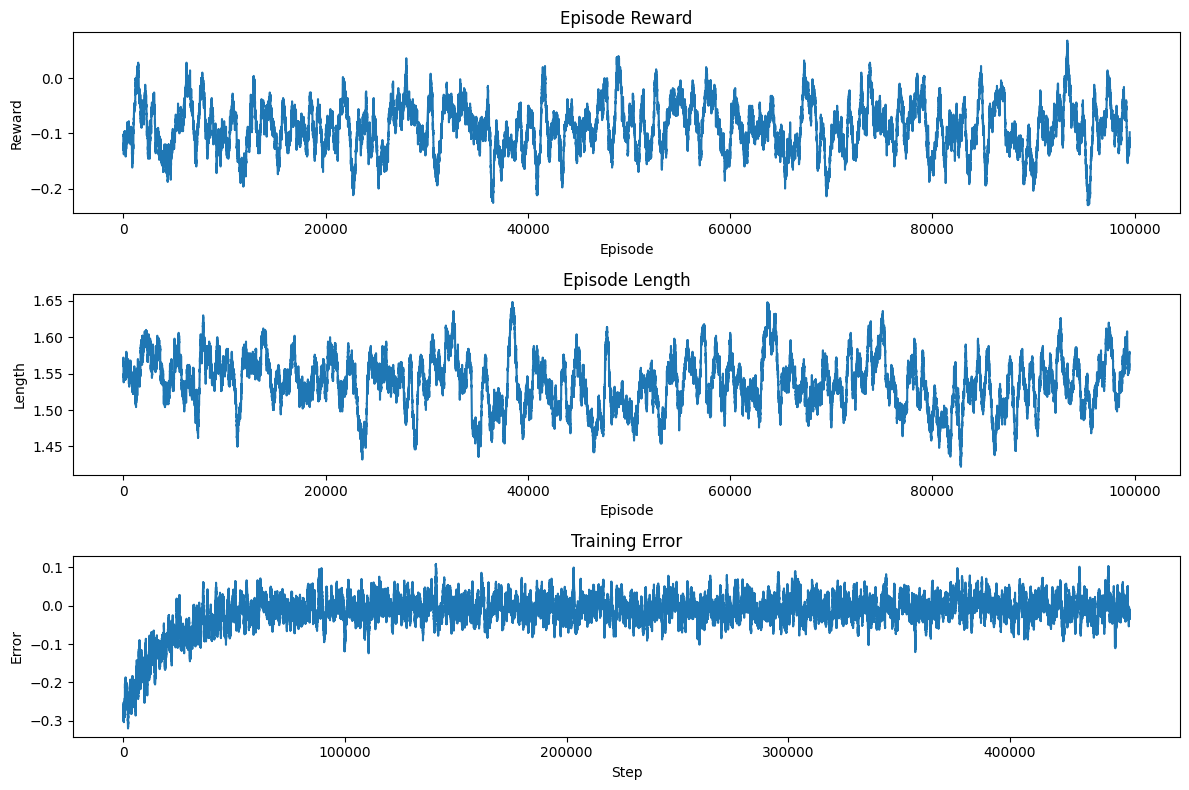

In [15]:
from matplotlib import pyplot as plt

def get_ma(arr, window, convolution_mode):
    return np.convolve(np.array(arr).flatten(), np.ones(window) / window, mode = convolution_mode)

rolling_length = 500

fig, axes = plt.subplots(3, 1, figsize = (12, 8))

axes[0].set_title("Episode Reward")
reward_ma = get_ma(env.return_queue, rolling_length, "valid")
axes[0].plot(range(len(reward_ma)), reward_ma)
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")

axes[1].set_title("Episode Length")
length_ma = get_ma(env.length_queue, rolling_length, "valid")
axes[1].plot(range(len(length_ma)), length_ma)
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Length")

axes[2].set_title("Training Error")
error_ma = get_ma(agent.training_err, rolling_length, "valid")
axes[2].plot(range(len(error_ma)), error_ma)
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Error")

plt.tight_layout()
plt.show()

In [21]:
def test_agent(env, agent, n_episodes = 1000):

    total_reward = []

    old_eps = agent.epsilon
    agent.epsilon = 0

    for _ in range(n_episodes):
        obs, info = env.reset()
        episode_reward =0
        done = False

        while not done:
            action = agent.get_action(obs)
            obs, rewards, terminated, truncated, info = env.step(action)
            episode_reward += rewards
            done = terminated or truncated 
            
        total_reward.append(episode_reward)

    agent.epsilon = old_eps

    win_rate   = np.mean(np.array(total_reward) > 0)
    avg_reward = np.mean(total_reward)

    print(f"Win Rate: {win_rate:.2f}, Avg Reward: {avg_reward:.2f}")
    print(f"Test results over {n_episodes} episodes")
    print(f"Standard Deviation: {np.std(total_reward):.2f}")

            

In [22]:
test_agent(env, agent)

Win Rate: 0.42, Avg Reward: -0.07
Test results over 1000 episodes
Standard Deviation: 0.95
